# IGANN: Interpretable Generalized Additive Neural Network

IGANN begins with a sparse linear model and stagewise fits feature-wise extreme-learning-machine corrections. Random hidden weights stay fixed; only output coefficients are solved.


## Model in one view


$$
F_T(x)=\beta_0+\sum_j\beta_jx_j+
\eta\sum_{t=1}^{T}\sum_j w_{tj}^{\mathsf T}\sigma(a_{tj}x_j).
$$

The stagewise residual fit lets a feature remain linear unless nonlinear corrections improve the objective.



IGANN starts from a sparse linear predictor and repeatedly fits weak nonlinear
feature-wise corrections to current residuals or gradients. Each correction
uses an extreme-learning-machine block: hidden weights are random and fixed,
while output weights are obtained from a regularized linear solve. The boost
rate shrinks each stage before it enters the ensemble.

This produces a useful hierarchy. Features remain linear when nonlinear stages
offer little gain, and become nonlinear only through accumulated corrections.
Early stopping controls functional complexity, while the optional sparse stage
controls how many atomic features may participate.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563EB", "#F97316", "#10B981", "#8B5CF6", "#EF4444"]

rng = np.random.default_rng(7)
n = 180
X = pd.DataFrame({
    "x1": rng.uniform(-1.0, 1.0, n),
    "x2": rng.normal(size=n),
    "group": rng.choice(["a", "b", "c"], size=n),
})
y = (
    np.sin(np.pi * X["x1"])
    + 0.35 * X["x2"] ** 2
    + 0.30 * (X["group"] == "b")
    + rng.normal(0.0, 0.12, n)
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)


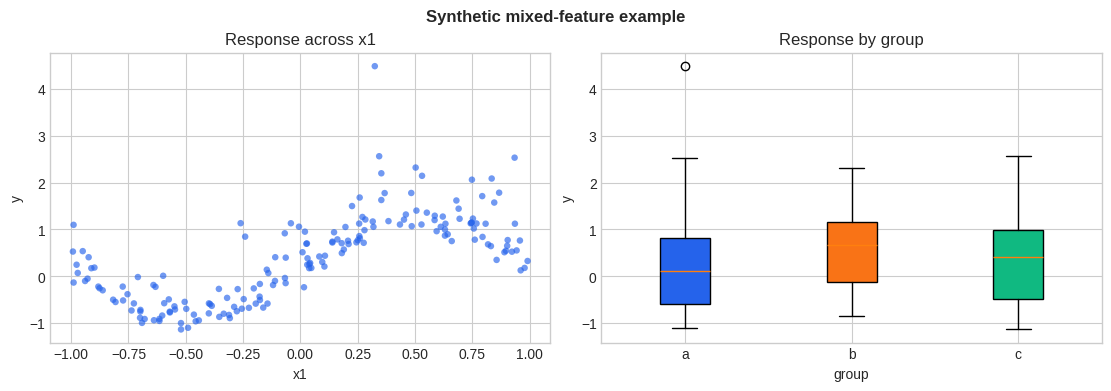

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].scatter(X["x1"], y, s=22, alpha=0.65, color=COLORS[0], edgecolor="none")
axes[0].set(title="Response across x1", xlabel="x1", ylabel="y")

group_order = ["a", "b", "c"]
group_values = [y[X["group"].to_numpy() == level] for level in group_order]
boxes = axes[1].boxplot(group_values, tick_labels=group_order, patch_artist=True)
for patch, color in zip(boxes["boxes"], COLORS, strict=False):
    patch.set_facecolor(color)
axes[1].set(title="Response by group", xlabel="group", ylabel="y")
fig.suptitle("Synthetic mixed-feature example", fontweight="bold")
plt.show()
plt.close(fig)


## Fit the model


In [3]:
from nampy.models import IGANNClassifier, IGANNLSS, IGANNRegressor


model = IGANNRegressor(
    n_hid=10,
    n_estimators=80,
    boost_rate=0.1,
    early_stopping=12,
    solver="native",
    sparse=0,
)
model.get_params(deep=False)


{'activation': 'elu',
 'boost_rate': 0.1,
 'clip_predictions': 100.0,
 'device': 'cpu',
 'early_stopping': 12,
 'elm_alpha': 1.0,
 'elm_random_state': 0,
 'elm_scale': 1.0,
 'init_reg': 1.0,
 'lr': 0.1,
 'lr_factor': 0.1,
 'lr_patience': 10,
 'lr_schedule': 'none',
 'n_estimators': 80,
 'n_hid': 10,
 'solver': 'native',
 'sparse': 0,
 'weight_decay': 0.0,
 'feature_preprocessing': None,
 'n_bins': 64,
 'numerical_preprocessing': 'none',
 'categorical_preprocessing': 'int',
 'use_decision_tree_bins': False,
 'binning_strategy': 'uniform',
 'task': 'regression',
 'cat_cutoff': 0.03,
 'treat_all_integers_as_numerical': False,
 'degree': 3,
 'scaling_strategy': None,
 'n_knots': 64,
 'use_decision_tree_knots': True,
 'knots_strategy': 'uniform',
 'spline_implementation': 'sklearn',
 'min_unique_vals': 5}

In [4]:
model.fit(
    X_train,
    y_train,
    max_epochs=3,
    batch_size=64,
    random_state=7,
    logger=False,
    enable_progress_bar=False,
    enable_model_summary=False,
)
predictions = model.predict(X_test)
r2 = model.score(X_test, y_test)
metrics = model.evaluate(X_test, y_test)
components = model.predict_components(X_test)
explanation = model.explain_terms(X_test, max_bins=24, center=True)
importance = model.term_importance(X_test, center=True)
interaction_importance = model.interaction_importance(X_test, center=True)
display({"R2": r2, **metrics})
display(importance)
display(explanation.head(12))


{'R2': 0.6158956890061211, 'Mean Squared Error': 0.26806953444506443}

,term,term_type,output,importance
0,x1,main,0,0.556960
1,x2,main,0,0.392561
2,group,main,0,0.127314


,term,term_type,output,value,contribution,count,importance
0,x1,main,0,-0.965,-1.235384,2,0.55696
1,x1,main,0,-0.8895,-1.192421,2,0.55696
2,x1,main,0,-0.7905,-0.987895,2,0.55696
3,x1,main,0,-0.6915,-0.880800,2,0.55696
4,x1,main,0,-0.58,-0.736988,2,0.55696
5,x1,main,0,-0.4875,-0.577293,2,0.55696
6,x1,main,0,-0.35,-0.330956,1,0.55696
7,x1,main,0,-0.209,-0.283711,2,0.55696
8,x1,main,0,-0.12505,-0.151723,2,0.55696
9,x1,main,0,-0.05205,-0.054109,2,0.55696


## Evaluate and explain


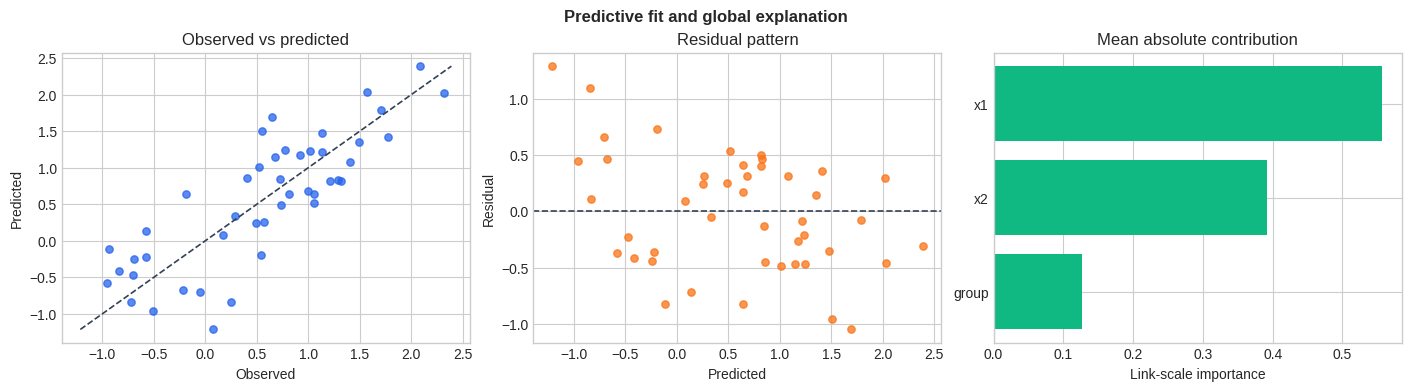

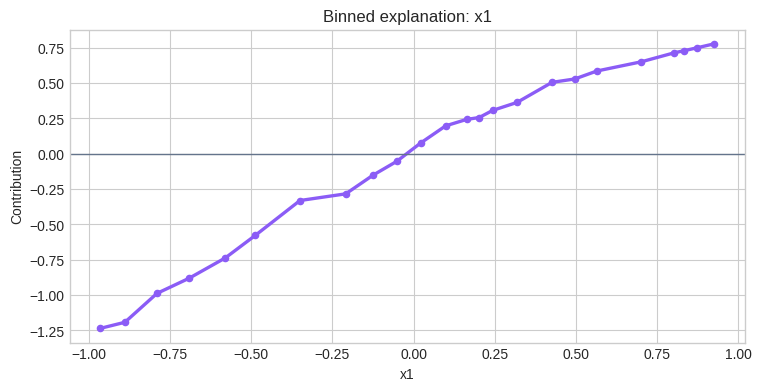

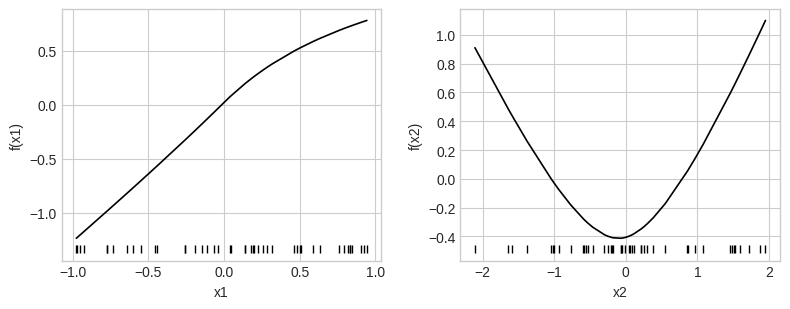

In [5]:
observed = np.asarray(y_test).reshape(-1)
fitted = np.asarray(predictions).reshape(-1)
residual = observed - fitted

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
axes[0].scatter(observed, fitted, s=28, alpha=0.75, color=COLORS[0])
lo = min(observed.min(), fitted.min())
hi = max(observed.max(), fitted.max())
axes[0].plot([lo, hi], [lo, hi], "--", color="#334155", linewidth=1.2)
axes[0].set(title="Observed vs predicted", xlabel="Observed", ylabel="Predicted")

axes[1].scatter(fitted, residual, s=28, alpha=0.75, color=COLORS[1])
axes[1].axhline(0.0, color="#334155", linestyle="--", linewidth=1.2)
axes[1].set(title="Residual pattern", xlabel="Predicted", ylabel="Residual")

importance_plot = (
    importance.groupby("term", as_index=False)["importance"]
    .mean()
    .sort_values("importance")
)
axes[2].barh(importance_plot["term"], importance_plot["importance"], color=COLORS[2])
axes[2].set(title="Mean absolute contribution", xlabel="Link-scale importance")
fig.suptitle("Predictive fit and global explanation", fontweight="bold")
plt.show()
plt.close(fig)

main_effects = explanation.loc[
    (explanation["term_type"] == "main") & (explanation["output"] == 0)
].copy()
main_effects["numeric_value"] = pd.to_numeric(main_effects["value"], errors="coerce")
main_effects = main_effects.dropna(subset=["numeric_value"])
if not main_effects.empty:
    numeric_terms = set(main_effects["term"])
    top_term = next(
        term
        for term in importance_plot.sort_values("importance", ascending=False)["term"]
        if term in numeric_terms
    )
    curve = main_effects.loc[main_effects["term"] == top_term].sort_values("numeric_value")
    if not curve.empty:
        fig, ax = plt.subplots(figsize=(7.5, 3.8), constrained_layout=True)
        ax.plot(curve["numeric_value"], curve["contribution"], color=COLORS[3], linewidth=2.4)
        ax.scatter(curve["numeric_value"], curve["contribution"], s=20, color=COLORS[3])
        ax.axhline(0.0, color="#64748B", linewidth=1)
        ax.set(title=f"Binned explanation: {top_term}", xlabel=top_term, ylabel="Contribution")
        plt.show()
        plt.close(fig)

term_figures = model.plot_terms(X_test, center=True, rug=True, pages=1)
interaction_terms = interaction_importance["term"].astype(str).tolist()
interactions_are_raw_columns = all(
    all(
        part in X_test.columns
        and pd.api.types.is_numeric_dtype(X_test[part])
        for part in term.split(":")
    )
    for term in interaction_terms
)
if interaction_terms and interactions_are_raw_columns:
    model.plot_interactions(X_test)


## Model-specific controls

`solver='native'` requests the upstream-style stagewise optimizer. `sparse>0` enables ABESS feature selection and requires the optional `igann-sparse` dependency.


In [6]:
display(model.training_history())
display(model.selected_features_)
display(model.basis_metadata())
display(model.model_complexity())


{'train_loss': (0.3913157880306244,
  0.3200944662094116,
  0.2953636646270752,
  0.28848958015441895,
  0.276737779378891,
  0.26893824338912964,
  0.2656204402446747,
  0.2634103298187256,
  0.26159533858299255,
  0.2602458596229553,
  0.25903579592704773,
  0.2583411931991577,
  0.25778764486312866,
  0.25742724537849426,
  0.257022887468338,
  0.2567242383956909,
  0.2564413249492645,
  0.25621119141578674,
  0.2559944987297058,
  0.2557569444179535,
  0.2555599510669708,
  0.25535130500793457,
  0.2551930248737335,
  0.2550669014453888,
  0.254406601190567,
  0.2542427182197571,
  0.25408247113227844,
  0.2539255917072296,
  0.2534347474575043,
  0.25323909521102905,
  0.2530766427516937,
  0.2528685927391052,
  0.25272050499916077,
  0.2524571120738983,
  0.2521955668926239,
  0.25194844603538513,
  0.25182488560676575,
  0.25151723623275757,
  0.25133559107780457,
  0.2512402832508087,
  0.25101304054260254,
  0.250849187374115,
  0.2505878210067749,
  0.25037503242492676,
  0.2

('x1', 'x2', 'group[1]', 'group[2]')

{'source_feature_names': ('x1', 'x2', 'group'),
 'atomic_feature_names': ('x1', 'x2', 'group[1]', 'group[2]'),
 'selected_features': ('x1', 'x2', 'group[1]', 'group[2]'),
 'hidden_weights': array([[[-1.1258398 , -1.1523602 , -0.25057858, -0.4338788 ,
           0.84871036,  0.69200915, -0.31601277, -2.1152194 ,
           0.32227492, -1.2633348 ],
         [ 0.93826073,  0.48886982,  1.2032237 ,  0.0845347 ,
          -1.2001394 , -0.00478574, -0.5180748 , -0.3067042 ,
          -1.5809939 ,  1.7066433 ]],
 
        [[-1.5255959 , -0.7502318 , -0.6539809 , -1.6094848 ,
          -0.10016718, -0.6091889 , -0.97977227, -1.6090963 ,
          -0.7121446 ,  0.303722  ],
         [ 0.7311667 ,  1.1718048 ,  2.4069781 ,  0.27856624,
           0.24675292,  1.1843266 , -0.7282137 ,  1.1632744 ,
          -0.00907459, -0.8424634 ]],
 
        [[-1.0408012 ,  0.91660416, -1.3041904 , -1.1096784 ,
          -1.2187781 ,  1.1675924 , -1.0573921 , -0.11883938,
          -0.90783983,  0.34522223],


{'total_parameters': 1765,
 'trainable_parameters': 0,
 'fitted_estimators': 38,
 'selected_features': 4,
 'effective_fitted_coefficients': 841}

## Supported task variants

Native training supports regression and binary classification. Multiclass `IGANNClassifier` and `IGANNLSS` use the fixed basis with the shared gradient engine.


In [7]:
task_variants = {"regression": IGANNRegressor(), "classification": IGANNClassifier(), "distributional": IGANNLSS()}


## References

- [Kraus et al. (2023), Interpretable Generalized Additive Neural Networks](https://doi.org/10.1016/j.ejor.2023.06.032).
